In [65]:
import pandas as pd

df = pd.read_csv("amazon_reviews.csv")
df.sample(5)

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
1379,1379,"DMFN ""DMFN""",1.0,I guess I should be happy it failed after only...,2013-01-23,684,1,0,1,1,1.0,0.206549
4057,4057,San Jose,5.0,"Stores thousands of pictures, and it worked pe...",2013-04-10,607,0,0,0,0,0.0,0.000000
3531,3531,PapaG,5.0,Bypass the &#34;cheaper&#34; clones and get Sa...,2014-05-07,215,0,0,0,0,0.0,0.000000
3532,3532,"papatech ""c.p.""",4.0,i just had an incident with my Galaxy S3 phone...,2013-07-02,524,0,0,0,0,0.0,0.000000
1175,1175,Darren,5.0,"I put this in my hp envy x2 to extend storage,...",2014-12-03,5,0,0,0,0,0.0,0.000000


In [66]:
df = df.drop("Unnamed: 0", axis=1)

In [67]:
df.shape

(4915, 11)

In [68]:
df.columns

Index(['reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff',
       'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff',
       'score_average_rating', 'wilson_lower_bound'],
      dtype='object')

In [69]:
df.isnull().sum()

reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [70]:
df = df.dropna()

In [74]:
df.shape

(4903, 13)

In [75]:
df.loc[:, "review_text"] = df["reviewText"].str.lower()

In [76]:
df = df[df["review_text"].str.len() > 10]

In [77]:
df.loc[:,"sentiment"] = df["overall"].apply(lambda x: 1 if x >= 4 else 0)

In [78]:
df["overall"].value_counts()

overall
5.0    3912
4.0     525
1.0     244
3.0     142
2.0      80
Name: count, dtype: int64

In [79]:
df["sentiment"].value_counts()

sentiment
1    4437
0     466
Name: count, dtype: int64

In [80]:
df = df[df["overall"] != 3]

In [81]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df.loc[:,"review_text"] = df["review_text"].apply(clean_text)

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# Train-test split (important: stratified)
X_train, X_test, y_train, y_test = train_test_split(
    df["review_text"],
    df["sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

# TF-IDF (optimized for text classification)
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.85,
    sublinear_tf=True,
    stop_words='english'
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Linear SVM with imbalance handling
svm_model = LinearSVC(
    class_weight='balanced',
    C=0.1,
    max_iter=5000
)

svm_model.fit(X_train_vec, y_train)

# Predictions
y_pred = svm_model.predict(X_test_vec)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 51  14]
 [ 39 849]]
              precision    recall  f1-score   support

           0       0.57      0.78      0.66        65
           1       0.98      0.96      0.97       888

    accuracy                           0.94       953
   macro avg       0.78      0.87      0.81       953
weighted avg       0.96      0.94      0.95       953



In [85]:
for c in [0.1, 0.5, 1, 2]:
    model = LinearSVC(class_weight='balanced', C=c, max_iter=5000)
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    print(f"\nC = {c}")
    print(classification_report(y_test, preds))


C = 0.1
              precision    recall  f1-score   support

           0       0.57      0.78      0.66        65
           1       0.98      0.96      0.97       888

    accuracy                           0.94       953
   macro avg       0.78      0.87      0.81       953
weighted avg       0.96      0.94      0.95       953


C = 0.5
              precision    recall  f1-score   support

           0       0.64      0.66      0.65        65
           1       0.98      0.97      0.97       888

    accuracy                           0.95       953
   macro avg       0.81      0.82      0.81       953
weighted avg       0.95      0.95      0.95       953


C = 1
              precision    recall  f1-score   support

           0       0.67      0.63      0.65        65
           1       0.97      0.98      0.98       888

    accuracy                           0.95       953
   macro avg       0.82      0.80      0.81       953
weighted avg       0.95      0.95      0.95      

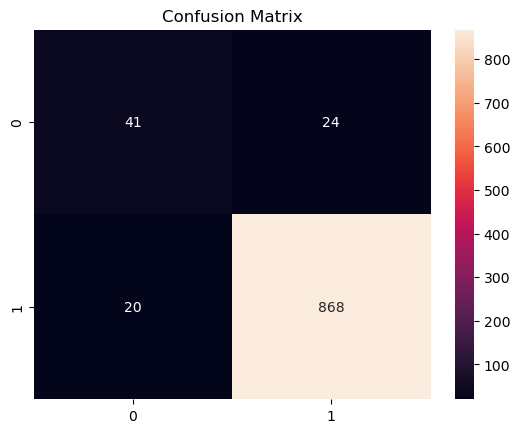

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [89]:
print("Train Accuracy:", model.score(X_train_vec, y_train))
print("Test Accuracy:", model.score(X_test_vec, y_test))

Train Accuracy: 0.9989495798319328
Test Accuracy: 0.9517313746065058


In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train_vec, y_train, cv=5)

print("Cross-validation scores:", scores)
print("Mean CV score:", scores.mean())

Cross-validation scores: [0.9671916  0.95144357 0.95406824 0.96057819 0.96320631]
Mean CV score: 0.9592975812320438


In [91]:
import joblib

joblib.dump(svm_model, "svm_sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']